In [36]:
from tqdm import tqdm
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import rasterio
from rasterio.windows import Window
from rasterio.plot import plotting_extent
from rasterio.transform import rowcol
from pyproj import Transformer

In [40]:
pd.read_csv(output_path, sep=",", header=0, index_col=0)

,Bad Bergzabern,Dahn,Pirmasens
1991-01-01,6.0,6.0,5.0
1991-01-02,9.0,9.0,7.0
1991-01-03,9.0,9.0,8.0
1991-01-04,8.0,8.0,6.0
1991-01-05,10.0,10.0,8.0
...,...,...,...
2026-02-24,6.0,6.0,6.0
2026-02-25,10.0,11.0,11.0
2026-02-26,14.0,14.0,15.0
2026-02-27,19.0,20.0,20.0


datetime: 1991-01-01 00:00:00
5.0
datetime: 1991-01-02 00:00:00
7.0
datetime: 1991-01-03 00:00:00
8.0
datetime: 1991-01-04 00:00:00
6.0
datetime: 1991-01-05 00:00:00
8.0


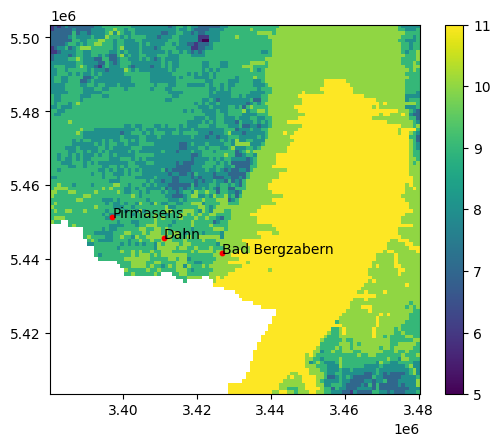

In [96]:
# Window to read
window = Window(
    col_off=100, row_off=600,
    width=100, height=100
)

# Open raster, read data
for path in pet_paths[0:5]:
    
    # Extrac date from filename
    datestring = path.stem.split("_")[-1]
    datetime = pd.to_datetime(datestring, format="%Y%m%d")
    print(f"datetime: {datetime}")
    
    
    with rasterio.open(path) as src:
        data = src.read(1, window=window)
        profile = src.profile
        transform = src.window_transform(window)

    # nodata
    nodata = src.nodata
    data = np.where(data == nodata, np.nan, data)


    # Extract pet at location
    row, col = rowcol(transform=transform, xs=x, ys=y)

    pet = data[row, col]
    print(pet)

# Plot
plt.imshow(
    data,
    extent = plotting_extent(data, transform),
    origin="upper"
)
plt.colorbar()
for key, (x, y) in locations_31467.items():
    plt.scatter(x, y, marker="o", s=10, c="red")
    plt.text(x, y, key)
plt.show()